# Variability

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

In [2]:
import os
import sys
import glob
import scipy
import random
import numpy as np
import pandas as pd
import scipy as sp
import scipy.stats as ss
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib import patches
from matplotlib.ticker import FuncFormatter
from astropy import units as u
from astropy.coordinates import SkyCoord
from pathlib import Path
from tqdm import tqdm 

# PlatoSim libraries
import platosim.plot      as pt
import platosim.starquery as sq
import platosim.utilities as ut
from platosim.simfile      import SimFile
from platosim.simulation   import Simulation
from platosim.lightcurve   import LightCurve
from platosim.matplotlibrc import setup_paper
setup_paper()

import warnings
warnings.simplefilter("ignore")

In [3]:
# Define paths used throughout
pdir = '/lhome/nicholas/software/workdir/mocka/plots'
fdir = '/lhome/nicholas/Nextcloud/paperMOCKA/figures'
path = '/lhome/nicholas/software/workdir/mocka'
idir = f'{path}/input'
vdir = '/lhome/nicholas/software/PlatoSim3/inputfiles/data_varsim'

---
## Synthetic SEDs for VarSim
---

In [ ]:
# Valid paramter space for PHOENIX spectra
valid_t_phoenix = np.array([*list(range(2300, 7000, 100)), 
                            *list((range(7000, 12200, 200)))])
valid_g_phoenix = np.array([*list(np.arange(0, 6, 0.5))])

# Valid parameter space for ATLAS9 spectra
valid_t_atlas9 = np.array([*list(range(3000, 1300, 250)), 
                           *list((range(13000, 50000, 1000)))])

In [ ]:
fig, ax = plt.subplots(1,1,figsize=(9,5))

for i in range(len(valid_g_phoenix)):
    ax.plot(valid_t_phoenix, np.ones_like(valid_t_phoenix)*valid_g_phoenix[i], 
            'o', c='royalblue', mec='w', ms=7)
    ax.plot(valid_t_atlas9,  np.ones_like(valid_t_atlas9)*valid_g_phoenix[i], 
            'd', c='deeppink', mec='w', ms=7)
    
ax.set_xlabel(r'$T_{\rm eff}$ [K]')
ax.set_ylabel('log $g$')
plt.tight_layout()

---
## Passband amplitude correction
---

In [ ]:
from platosim.spectrum  import Spectrum

# Get passbands
odir = os.getenv("PLATO_PROJECT_HOME") + "/inputfiles/data_varsim"
N = 10000
wave_a, tran_a = ut.get_passband('plato', response='absolute', interpolate=True, n=N)
wave_b, tran_b = ut.get_passband('tess', response='absolute', interpolate=True, n=N)

In [ ]:
# Load a PHOENIX star
spec = Spectrum(verbose=1)
Teff, logg, Z, alpha = spec.nearest_parameters(5800, 4.5, 0, 0, 'PhoenixHiRes')
wave_star, flux_star = spec.getPhoenixHiResFITS(Teff, logg, Z, alpha)
wave_star /= 10 # [AA -> nm]

# Find passband region and interpolate
dex_wave_min_a = ut.findNearestIndex(wave_star, wave_a[0])
dex_wave_max_a = ut.findNearestIndex(wave_star, wave_a[-1])
wave_star_a = wave_star[dex_wave_min_a:dex_wave_max_a]
flux_star_a = flux_star[dex_wave_min_a:dex_wave_max_a]
wave_equi_a, flux_equi_a = ut.rebin3(wave_a, wave_star, flux_star)

dex_wave_min_b = ut.findNearestIndex(wave_star, wave_b[0])
dex_wave_max_b = ut.findNearestIndex(wave_star, wave_b[-1])
wave_star_b = wave_star[dex_wave_min_b:dex_wave_max_b]
flux_star_b = flux_star[dex_wave_min_b:dex_wave_max_b]
wave_equi_b, flux_equi_b = ut.rebin3(wave_b, wave_star, flux_star)

# Flux within passbands
flux_tran_a = flux_equi_a * tran_a
flux_tran_b = flux_equi_b * tran_b

# Integrate to find ratio for correction
flux_a = np.trapz(flux_tran_a, wave_equi_a)
flux_b = np.trapz(flux_tran_b, wave_equi_b)

# Plot T x F
plt.figure()
plt.plot(wave_equi_a, flux_tran_a, 'k-')
plt.plot(wave_equi_b, flux_tran_b, 'r-')

print(f'Passband correction: {flux_a/flux_b:.3f}')

In [ ]:
# Code to create absolute response for TESS
# corr = 0.78
# plt.figure()
# plt.plot(wave_b, tran_b * corr, 'k-')
# tran_abs = tran_b * corr
# df = pd.DataFrame({'wavelength':wave_b, 'absolute':tran_abs, 'relative':tran_b})
# df.to_csv('/STER/platoman/ftp/passband_tess_new.txt', index=False)

---
## $\gamma$ Doradus- stars (Gang+2020)
---

### Modes in period-spacing pattern

In [19]:
# Units: freq [], ampl []
filenames_all = glob.glob(f'{vdir}/varsource_gdor_gang2020/*.dat')
filenames = glob.glob(f'{vdir}/varsource_gdor_gang2020_pattern/*')
N = len(filenames)
N_mod = np.zeros(N)
P0    = np.zeros(N)
dP0   = np.zeros(N)
slope = np.zeros(N)
A_max = np.zeros(N)
n_off = np.zeros(N)
df = pd.DataFrame()
da = pd.DataFrame()

# Loop over each star
for i,f in zip(range(N), tqdm(filenames, bar_format=ut.tqdmBar())):
    starfiles = glob.glob(f'{f}/*')
        
    # For each star check each file 
    for s in starfiles:

        # Load only dipole sectoral modes (l,m)=(1,1)
        if s[-18:-15] == 'k=0' and s[-14:-11] == 'm=1':
            
            # Here missing modes are included as 9999.
            dv_i = pd.read_csv(s, sep=' ', skiprows=1, names=['per', 'per_err'])
            
            # Calculate period spacings [days]
            n = int(dv_i.shape[0])-1
            dx = pd.DataFrame()
            dx['delta_P'] = dv_i.per.diff().dropna()
            dx['P_mean']  = np.array([(dv_i.per[j] + dv_i.per[j+1])/2. for j in range(n)])
            
            # Remove mising modes and store periods
            df_i = dv_i[~(dv_i.per == 9999.0)]  
            
            # Number of modes (including missing ones)
            N_mod[i] = df_i.shape[0]
            
            # First period in pattern [days]
            P0[i] = df_i.per.iloc[0]
            
            # Remove undefined modes
            dx = dx[~(dx.delta_P.abs() > 10) & ~(dx.delta_P.abs() == 0.0)]
            
            # First period spacing
            dP0[i] = dx.delta_P.iloc[0]
            
            # Fit and find slope
            coeff = np.polyfit(dx.P_mean, dx.delta_P, 1)
            slope[i] = coeff[0]
            
            # Lastly fetch amplitudes by matching to all freqs
            f0 = Path(filenames_all[0])
            f1 = f0.parent / (Path(s).stem[:12] + 'very_deep_clean.dat')
            dx_i = pd.read_csv(f1, sep=' ', comment='#', names=['per', 'amp', 'phi', 'snr'])
            dex = []
            for p in df_i.per:
                dex.append(ut.findNearestIndex(dx_i.per, p))
            dx_i = dx_i.loc[dex].reset_index()
            
            # Maximum amplitude
            A_max[i] = dx_i.amp.max()
            
            # Store amplitudes
            df = pd.concat([df, df_i]) 
            da = pd.concat([da, dx_i])
                        
#---------- Test a single star -----------
#             n_off[i] = dx_i.amp.idxmax() / dx_i.shape[0] #/ dx_i.shape[0]       
#     if i == 20:
#         break
#-----------------------------------------

# Create data frame
dm = pd.DataFrame()
dm['N'] = N_mod
dm['P0'] = P0
dm['dP0'] = dP0
dm['slope'] = slope

# Remove star with no clear patterns
dm = dm[~(dm.N == 0.0)]

# Generate data to be used in varsim
# dm = dm.reset_index(drop=True)
# dm.to_feather(f'{vdir}/varsim_mocka_gdor_gang2020.ftr')

100%|█████████████████████████████████████████████████▉| 608/609 [00:04<00:00, 1


In [20]:
# Generate KDEs
N_kde     = scipy.stats.gaussian_kde(dm.N)
P0_kde    = scipy.stats.gaussian_kde(dm.P0)
dP0_kde   = scipy.stats.gaussian_kde(dm.dP0)
slope_kde = scipy.stats.gaussian_kde(dm.slope)

# Fit log-norm function to mode amplitudes
grid = 10000
A_mag  = da.amp
A_max  = A_max  * 1e3
A_mmag = da.amp * 1e3
A_range_mag  = np.linspace(0, A_mag.max(), grid)
A_range_max  = np.linspace(0, A_max.max(), grid)
A_range_mmag = np.linspace(0, A_mmag.max(), grid)
param_mag  = ss.lognorm.fit(A_mag)
param_mmag = ss.lognorm.fit(A_mmag)
A_lognorm_mag  = ss.lognorm.pdf(A_range_mag,  param_mag[0],  loc=param_mag[1],  scale=param_mag[2]) + 5e-5
A_lognorm_mmag = ss.lognorm.pdf(A_range_mmag, param_mmag[0], loc=param_mmag[1], scale=param_mmag[2]) + 5e-5

# Fit coefficient used by varsim
print(param_mag)
print(param_mmag)

(1.317739251804005, 2.180862377710758e-06, 3.1560729171583935e-05)
(1.3177392518412796, 0.0021808623780934554, 0.03156072917069115)


<IPython.core.display.Javascript object>


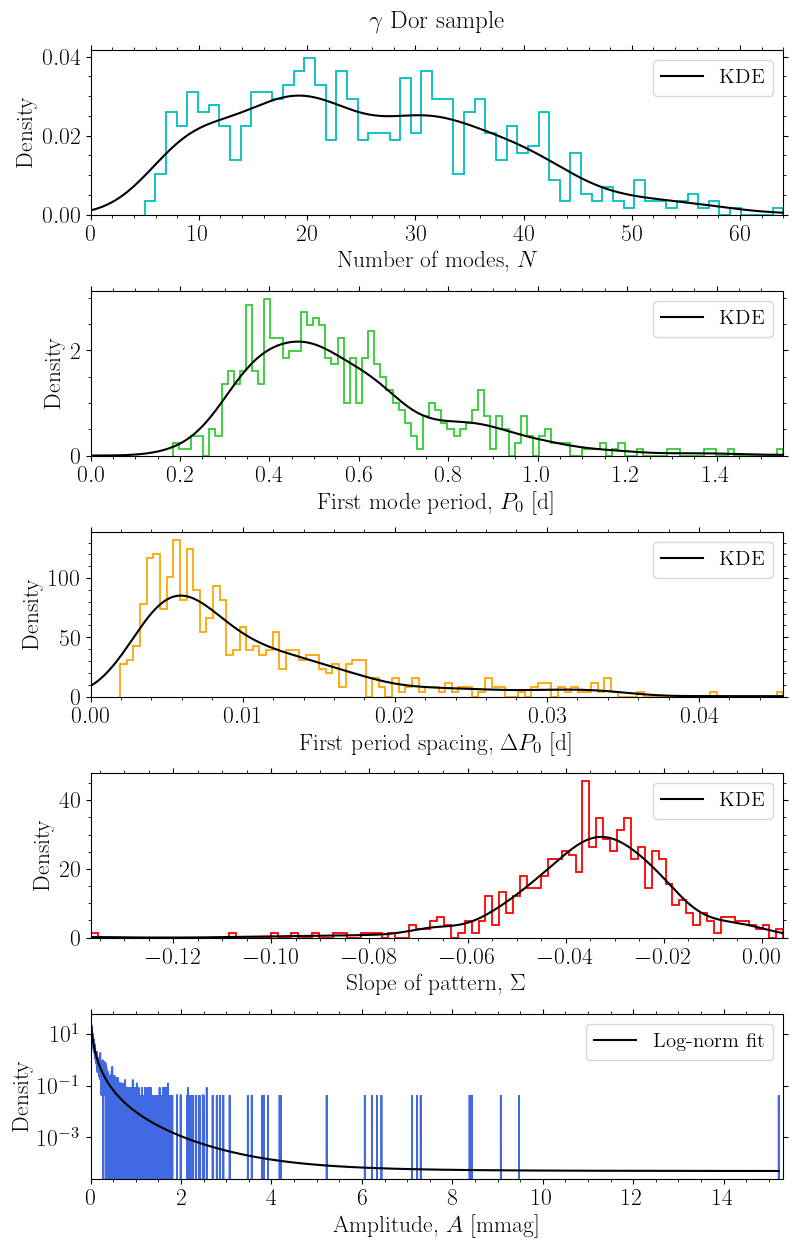

In [21]:
# Histograms
panels = 5
fig, ax = plt.subplots(panels, 1, figsize=(8, 2.5*panels))

h = ax[0].hist(dm.N, bins=60, histtype='step', density=True, ec='c', lw=1.3)
N_range = np.linspace(0, h[1].max(), grid)
N_kde_hist = N_kde(N_range)
ax[0].plot(N_range, N_kde_hist, 'k-', label='KDE')
ax[0].set_xlim(0, N_range.max())
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(dm.P0, bins=100, histtype='step', density=True, ec='limegreen', lw=1.3)
P0_range = np.linspace(0, h[1].max(), grid)
P0_kde_hist = P0_kde(P0_range)
ax[1].plot(P0_range, P0_kde_hist, 'k-', label='KDE')
ax[1].set_xlim(0, P0_range.max())
ax[1].set_xlabel(r'First mode period, $P_0$ [d]')

h = ax[2].hist(dm.dP0, bins=100, histtype='step', density=True, ec='orange', lw=1.3)
dP0_range = np.linspace(0, h[1].max(), grid)
dP0_kde_hist = dP0_kde(dP0_range)
ax[2].plot(dP0_range, dP0_kde_hist, 'k-', label='KDE')
ax[2].set_xlim(0, dP0_range.max())
ax[2].set_xlabel(r'First period spacing, $\Delta P_0$ [d]')

h = ax[3].hist(dm.slope, bins=100, histtype='step', density=True, ec='red', lw=1.3)
slope_range = np.linspace(h[1].min(), h[1].max(), grid)
slope_kde_hist = slope_kde(slope_range)
ax[3].plot(slope_range, slope_kde_hist, 'k-', label='KDE')
ax[3].set_xlim(slope_range.min(), slope_range.max())
ax[3].set_xlabel(r'Slope of pattern, $\Sigma$')

ax[4].hist(A_mmag, bins=10000, histtype='step', density=True, ec='royalblue', lw=1.3)
ax[4].plot(A_range_mmag, A_lognorm_mmag, 'k-', label='Log-norm fit')
ax[4].set_xlabel(r'Amplitude, $A$ [mmag]')
ax[4].set_ylabel('Density')
ax[4].set_yscale('log')
ax[4].set_xlim(0, A_mmag.max()+0.1)
# For log plot
# ax[4].set_xscale('log')
# ax[4].set_xlim(2e-3, 20)

ax[0].set_title(r'$\gamma$ Dor sample', pad=15, fontsize=18)
for i in range(panels): 
    ax[i].set_ylabel('Density')
    ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{pdir}/varsource_hist_GDOR.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


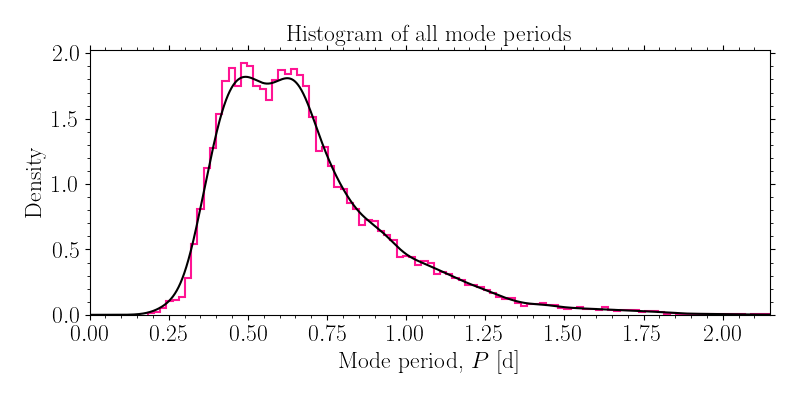

In [22]:
# Check range of mode periods
fig, ax = plt.subplots(1, 1, figsize=(8,4))
h = ax.hist(df.per, bins=100, histtype='step', density=True, ec='deeppink', lw=1.5)
P_kde = scipy.stats.gaussian_kde(df.per)
P_range = np.linspace(0, h[1].max(), grid)
P_kde_hist = P_kde(P_range)
ax.plot(P_range, P_kde_hist, 'k-', label='KDE')
ax.set_xlim(0, P_range.max())
ax.set_xlabel(r'Mode period, $P$ [d]')
ax.set_ylabel('Density')
ax.set_title('Histogram of all mode periods')
plt.tight_layout()

### Test that amplitudes are correct

<IPython.core.display.Javascript object>


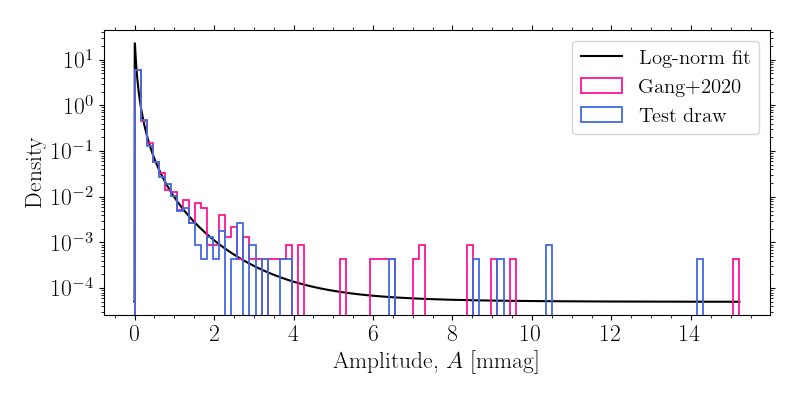

In [23]:
# TEST LOG-NORM AMPLITUDE METHODOLOGY

# Random draws using weights
N = len(A_mmag)
A_i = np.array(random.choices(A_range_mmag, A_lognorm_mmag, k=N)) 
Amax = np.max([A_mmag, A_i])

# Inspect uncertainties
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.plot(A_range_mmag, A_lognorm_mmag, 'k-', label='Log-norm fit')
ax.hist(A_mmag, bins=100, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='deeppink',  label='Gang+2020')
ax.hist(A_i,    bins=100, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='royalblue', label='Test draw')
ax.set_xlabel(r'Amplitude, $A$ [mmag]')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()

In [91]:
# TEST HOW WELL WE RECOVER MAX AMPLITUDE DISTRIBUTION OF GANG+2020
rng = ut.rng()
m = len(A_max)
A_max_draw = np.zeros(m)
for i in tqdm(range(m), bar_format=ut.tqdmBar()):
    N = int(random.choices(N_range, weights=N_kde(N_range), k=1)[0])
    if N < 5: N = 5
    n = rng.integers(10000, 100000, 1)[0]
    A_i_ran = np.linspace(0, A_max.max(), n)
    A_i_fit = scipy.stats.lognorm.pdf(A_i_ran, param_mmag[0], loc=param_mmag[1], scale=param_mmag[2])
    A_i = np.array(random.choices(A_i_ran, weights=A_i_fit, k=N))
    A_max_draw[i] = A_i.max()
    
# Plot max amplitude distibutions
Amax = np.max([A_max.max(), A_max_draw.max()])
fig, ax = plt.subplots(1, 1, figsize=(8,4))
h = ax.hist(A_max,      bins=100, range=(0, Amax), histtype='step', density=True, lw=1.5, ec='deeppink',  label='Gang+2021')
h = ax.hist(A_max_draw, bins=100, range=(0, Amax), histtype='step', density=True, lw=1.5, ec='royalblue', label='Simulated')
ax.set_xlim(0, A_range_max.max())
ax.set_title('Validation of max amplitudes')
ax.set_xlabel(r'Max mode amplitude, $A_{\rm max}$ [mmag]')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()

100%|██████████████████████████████████████████████████| 609/609 [01:01<00:00,  


### Model period pattern slope

In [ ]:
# Use correct stellar rotation (slope) from fit
def func(x, a, b, c, d, e):
    return  a * np.exp(-b * x) + c * np.log10(d * x) + e
P0_range  = np.linspace(dm.P0.min(), dm.P0.max(), 100)
popt, pcov = curve_fit(func, dm.P0, dm.slope)

# Fit coefficients used by varsim
print(popt)

In [ ]:
# Plot period spacing pattern
fig, ax = plt.subplots(1, 1, figsize=(7.7,7))

im0 = ax.scatter(dm.P0, dm.slope, c=dm.dP0, edgecolors='lightgray', cmap='viridis')
ax.plot(P0_range, func(P0_range, *popt), 'r-')
ax.set_xlabel('First period, $P_0$ [day]')
ax.set_ylabel('Slope, $\Sigma$')
cbar = plt.colorbar(im0, orientation='horizontal', location='top', extend='both', 
                   anchor=(0.8, -6.5), shrink=0.7, aspect=25)
cbar.set_label(r"First period-spacing, $\Delta P_0$ [day]", labelpad=10)                                    
plt.tight_layout()

# Save figure
# fig.savefig(f'{fdir}/gdor_dipole_mode_correlation.png', bbox_inches='tight', dpi=200)

### Model used by varsim

In [ ]:
# Select number modes
N_ran = np.arange(dm.N.min(), dm.N.max(), 1)
N = int(random.choices(N_ran, weights=N_kde(N_ran), k=1)[0])
# N = pd.Series(N_ran).sample(1, weights=N_kde(N_ran)).to_numpy()[0]
N = int(N)

# Randomly select grid step
n = self.rng.integers(10000, 100000, 1)[0]

# Select maximum period from KDE
P0_ran = np.linspace(dm.P0.min(), dm.P0.max(), n)
P0 = random.choices(P0_ran, weights=P0_kde(P0_ran), k=1)[0]
# P0 = pd.Series(P0_ran).sample(1, weights=P0_kde(P0_ran)).to_numpy()[0]

# First period spacing in pattern from KDE
dP0_ran = np.linspace(dm.dP0.min(), dm.dP0.max(), n)
dP0 = random.choices(dP0_ran, weights=dP0_kde(dP0_ran), k=1)[0]
# dP0 = pd.Series(dP0_ran).sample(1, weights=dP0_kde(dP0_ran)).to_numpy()[0]

# Slope of pattern from fit
slope = func(P0, *popt)

# Create period-spacing pattern
P_i = np.array([dP0 * ((1 + slope)**i - 1)/slope + P0 for i in range(N)])

# Draw amplitude below maximum
A_i_ran = np.linspace(0, A_mag.max(), n)
param = [1.3177087487666639, 0.0021808585006446645, 0.03156249403328485]
A_i_fit = ss.lognorm.pdf(A_i_ran, param[0], loc=param[1], scale=param[2])
A_i = np.array(random.choices(A_i_ran, weights=A_i_fit, k=N))
# A_i = pd.Series(A_i_ran).sample(N, weights=A_i_fit).to_numpy()

# Max peak amplitude
n_max = np.argmax(A_i)
A_max0 = A_i[n_max]

# Swap max peak location with offset
n_off = np.random.randint(-5, 5)
n_dex = int(N/2 + n_off)
if n_dex > n_off/2: n_dex = int(n_dex - 1) 
A_i[n_max] = A_i[n_dex]
A_i[n_dex] = A_max0

# Draw random periods not part of the pattern
M = np.random.randint(100, 300)
P_puls_i = np.random.uniform(0, 2, size=M)
A_puls_i = np.random.uniform(0, A_max0/8, size=M)

# Plot periodogram
fig, ax = plt.subplots(1,1, figsize=(8,4))
for i in range(N):
    ax.vlines(x=P_i[i], ymin=0, ymax=A_i[i]*1e3, colors='b', label='Pattern')
for i in range(M):
    ax.vlines(x=P_puls_i[i], ymin=0, ymax=A_puls_i[i]*1e3, colors='r', label='Extra pulsations')
ax.vlines(x=P_i[n_dex], ymin=0, ymax=A_i[n_dex]*1e3, colors='g', label='Max puls')
plt.title(f'Number of modes: {N}')
plt.xlabel(r'Period, $P$ [day]')
plt.ylabel(r'Amplitude, $A$ [mmag]')
plt.xlim(0, 2)
plt.tight_layout()

---
## SPB stars (Pedersen+2021)
---

In [35]:
filenames = glob.glob(f'{vdir}/varsource_SPB_pedersen2021/*.dat')
N = len(filenames)
N_mod = np.zeros(N)
P0    = np.zeros(N)
dP0   = np.zeros(N)
slope = np.zeros(N)
A_max = np.zeros(N)
df = pd.DataFrame()
dm = pd.DataFrame()

for i,f in zip(range(N), tqdm(filenames, bar_format=ut.tqdmBar())):
    
    # Load data
    dn_i = np.loadtxt(filenames[i], comments='#', usecols=[0,2])
    dv_i = pd.DataFrame({'per':dn_i[:,0], 'ampl':dn_i[:,1]})
    
    # Calculate period spacings [days]
    n = int(dv_i.shape[0])-1
    dx_i = pd.DataFrame()
    dx_i['delta_P'] = dv_i.per.diff().dropna()
    dx_i['P_mean']  = np.array([(dv_i.per[j] + dv_i.per[j+1])/2. for j in range(n)])
            
    # Remove mising modes and store periods
    df_i = dv_i[~(dv_i.per == 9999.0)]  
    
    # Number of modes (including missing ones)
    N_mod[i] = df_i.shape[0]
            
    # First period in pattern [days]
    P0[i] = df_i.per.iloc[0]
    
    # First period spacing
    dP0[i] = dx_i.delta_P.iloc[0]
            
    # Fit and find slope
    coeff = np.polyfit(dx_i.P_mean, dx_i.delta_P, 1)
    slope[i] = coeff[0]
    
    # Maximum mode amplitude
    A_max[i] = df_i.ampl.max() 
    
    # Store all modes and amplitudes
    df = pd.concat([df, df_i])
    
# Create data frame
dm = pd.DataFrame()
dm['N'] = N_mod
dm['P0'] = P0
dm['dP0'] = dP0
dm['slope'] = slope
dm['Amax'] = -2.5*np.log10(1-A_max/1e6)
A_max  = dm.Amax * 1e3
A_mag  = -2.5*np.log10(1-df.ampl/1e6)
A_mmag = A_mag * 1e3

# Generate data to be used in varsim
# dm = dm.reset_index(drop=True)
# dm.to_feather(f'{vdir}/varsim_mocka_SPB_pedersen2021.ftr')

 97%|████████████████████████████████████████████████▋ | 38/39 [00:00<00:00, 445


In [41]:
# Generate KDEs
N_kde     = scipy.stats.gaussian_kde(dm.N)
P0_kde    = scipy.stats.gaussian_kde(dm.P0)
dP0_kde   = scipy.stats.gaussian_kde(dm.dP0)
slope_kde = scipy.stats.gaussian_kde(dm.slope)
# Amax_kde  = scipy.stats.gaussian_kde(dm.Amax)

# Fit log-norm function to mode amplitudes
grid = 10000
A_range_mag  = np.linspace(0, A_mag.max(), grid)
A_range_max  = np.linspace(0, A_max.max(), grid)
A_range_mmag = np.linspace(0, A_mmag.max(), grid)
param_mag  = ss.lognorm.fit(A_mag)
param_mmag = ss.lognorm.fit(A_mmag)
A_lognorm_mag  = ss.lognorm.pdf(A_range_mag,  param_mag[0],  loc=param_mag[1],  scale=param_mag[2])  + 5e-5
A_lognorm_mmag = ss.lognorm.pdf(A_range_mmag, param_mmag[0], loc=param_mmag[1], scale=param_mmag[2]) + 5e-5

# Fit coefficient used by varsim
param_mag

(1.4225080146060183, 8.415648200068788e-07, 0.00012715214085614303)

<IPython.core.display.Javascript object>


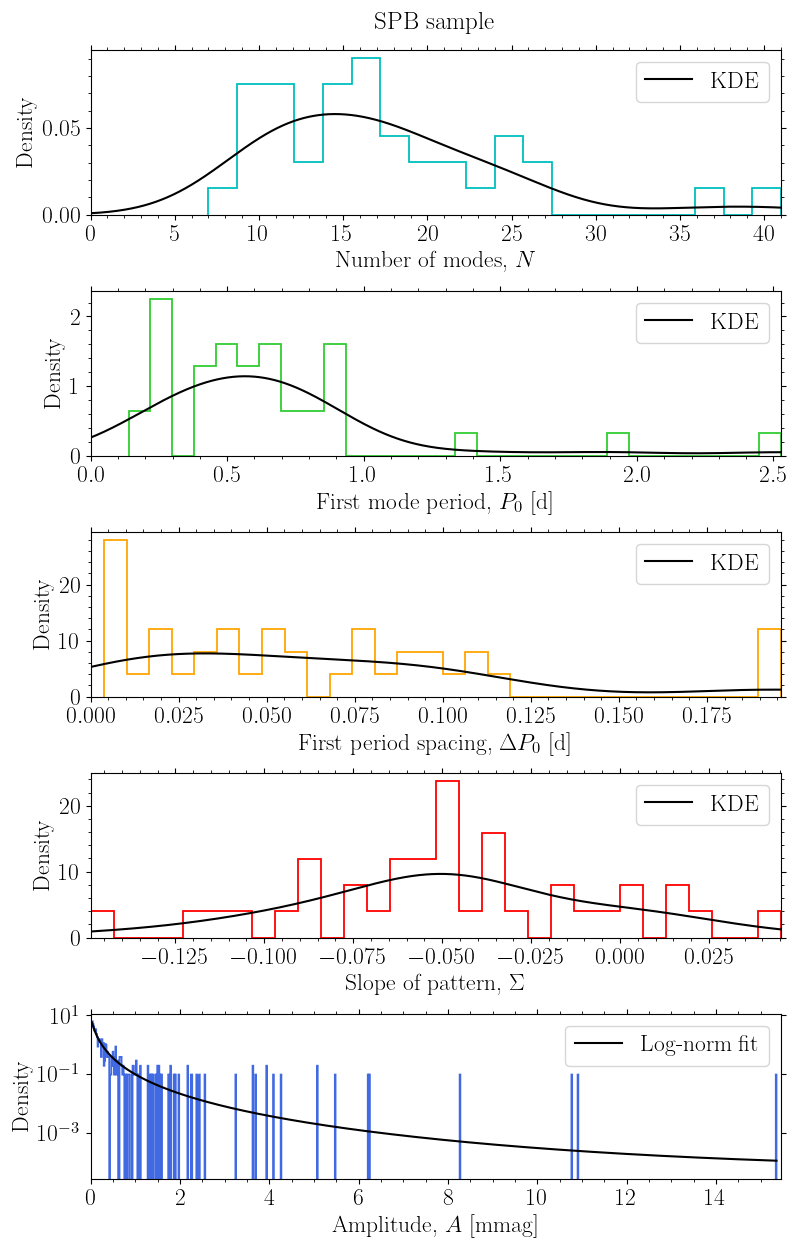

In [42]:
# Histograms
panels = 5
fig, ax = plt.subplots(panels, 1, figsize=(8, 2.5*panels))

h = ax[0].hist(dm.N, bins=20, histtype='step', density=True, ec='c', lw=1.3)
N_range = np.linspace(0, h[1].max(), grid)
N_kde_hist = N_kde(N_range)
ax[0].plot(N_range, N_kde_hist, 'k-', label='KDE')
ax[0].set_xlim(0, N_range.max())
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(dm.P0, bins=30, histtype='step', density=True, ec='limegreen', lw=1.3)
P0_range = np.linspace(0, h[1].max(), grid)
P0_kde_hist = P0_kde(P0_range)
ax[1].plot(P0_range, P0_kde_hist, 'k-', label='KDE')
ax[1].set_xlim(0, P0_range.max())
ax[1].set_xlabel(r'First mode period, $P_0$ [d]')

h = ax[2].hist(dm.dP0, bins=30, histtype='step', density=True, ec='orange', lw=1.3)
dP0_range = np.linspace(0, h[1].max(), grid)
dP0_kde_hist = dP0_kde(dP0_range)
ax[2].plot(dP0_range, dP0_kde_hist, 'k-', label='KDE')
ax[2].set_xlim(0, dP0_range.max())
ax[2].set_xlabel(r'First period spacing, $\Delta P_0$ [d]')

h = ax[3].hist(dm.slope, bins=30, histtype='step', density=True, ec='red', lw=1.3)
slope_range = np.linspace(h[1].min(), h[1].max(), grid)
slope_kde_hist = slope_kde(slope_range)
ax[3].plot(slope_range, slope_kde_hist, 'k-', label='KDE')
ax[3].set_xlim(slope_range.min(), slope_range.max())
ax[3].set_xlabel(r'Slope of pattern, $\Sigma$')

ax[4].hist(A_mmag, bins=1000, histtype='step', density=True, ec='royalblue', lw=1.3)
ax[4].plot(A_range_mmag, A_lognorm_mmag, 'k-', label='Log-norm fit')
ax[4].set_xlabel(r'Amplitude, $A$ [mmag]')
ax[4].set_ylabel('Density')
ax[4].set_yscale('log')
ax[4].set_xlim(0, A_mmag.max()+0.1)
#---- For log plot
# ax[4].set_xscale('log')
# ax[4].set_xlim(2e-3, 20)

ax[0].set_title('SPB sample', pad=15, fontsize=18)
for i in range(panels): 
    ax[i].set_ylabel('Density')
    ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{pdir}/varsource_hist_SPB.png', bbox_inches='tight', dpi=200)

<IPython.core.display.Javascript object>


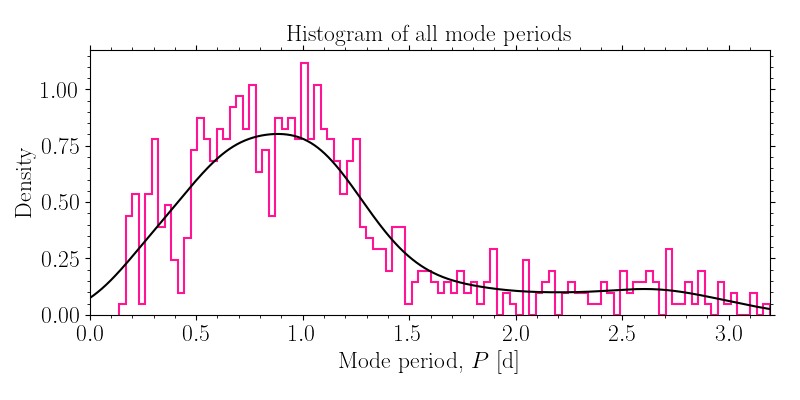

In [43]:
# Check the range of mode periods
fig, ax = plt.subplots(1, 1, figsize=(8,4))
h = ax.hist(df.per, bins=100, histtype='step', density=True, ec='deeppink', lw=1.5)
P_kde = scipy.stats.gaussian_kde(df.per)
P_range = np.linspace(0, h[1].max(), grid)
P_kde_hist = P_kde(P_range)
ax.plot(P_range, P_kde_hist, 'k-', label='KDE')
ax.set_xlim(0, P_range.max())
ax.set_xlabel(r'Mode period, $P$ [d]')
ax.set_ylabel('Density')
ax.set_title('Histogram of all mode periods')
plt.tight_layout()

### Test that amplitudes are correct

<IPython.core.display.Javascript object>


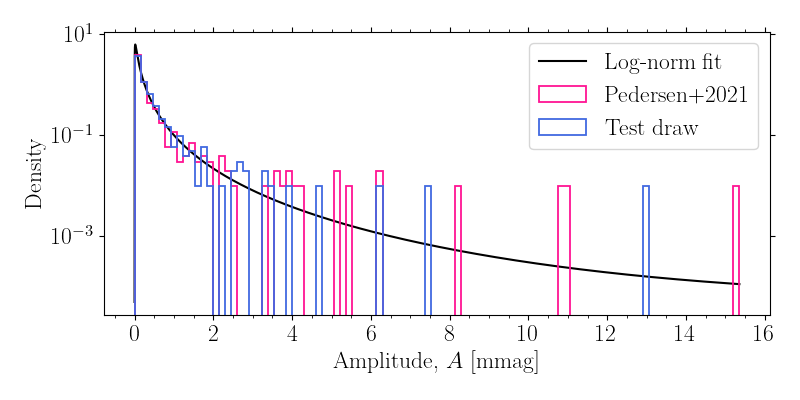

In [47]:
# TEST LOG-NORM AMPLITUDE METHODOLOGY

# Random draws using weights
N = len(A_mmag)
A_i = np.array(random.choices(A_range_mmag, A_lognorm_mmag, k=N)) 
Amax = np.max([A_mmag, A_i])

# Inspect uncertainties
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.plot(A_range_mmag, A_lognorm_mmag, 'k-', label='Log-norm fit')
ax.hist(A_mmag, bins=100, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='deeppink',  label='Pedersen+2021')
ax.hist(A_i,    bins=100, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='royalblue', label='Test draw')
ax.set_xlabel(r'Amplitude, $A$ [mmag]')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()

100%|██████████████████████████████████████████████████| 39/39 [00:00<00:00, 63.


<IPython.core.display.Javascript object>


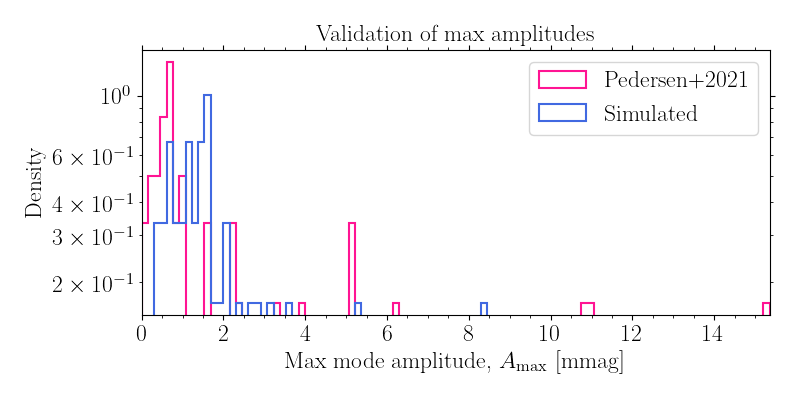

In [53]:
# TEST HOW WELL WE RECOVER MAX AMPLITUDE DISTRIBUTION OF GANG+2020
rng = ut.rng()
m = len(A_max)
A_max_draw = np.zeros(m)
for i in tqdm(range(m), bar_format=ut.tqdmBar()):
    N = int(random.choices(N_range, weights=N_kde(N_range), k=1)[0])
    if N < 5: N = 5
    n = rng.integers(10000, 100000, 1)[0]
    A_i_ran = np.linspace(0, A_max.max(), n)
    A_i_fit = scipy.stats.lognorm.pdf(A_i_ran, param_mmag[0], loc=param_mmag[1], scale=param_mmag[2])
    A_i = np.array(random.choices(A_i_ran, weights=A_i_fit, k=N))
    A_max_draw[i] = A_i.max()
    
# Plot max amplitude distibutions
Amax = np.max([A_max.max(), A_max_draw.max()])
fig, ax = plt.subplots(1, 1, figsize=(8,4))
h = ax.hist(A_max,      bins=100, range=(0, Amax), histtype='step', density=True, lw=1.5, ec='deeppink',  label='Pedersen+2021')
h = ax.hist(A_max_draw, bins=100, range=(0, Amax), histtype='step', density=True, lw=1.5, ec='royalblue', label='Simulated')
ax.set_xlim(0, A_range_max.max())
ax.set_title('Validation of max amplitudes')
ax.set_xlabel(r'Max mode amplitude, $A_{\rm max}$ [mmag]')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()

### Model period pattern slope
We do not use this as there is no clear trend!

<IPython.core.display.Javascript object>


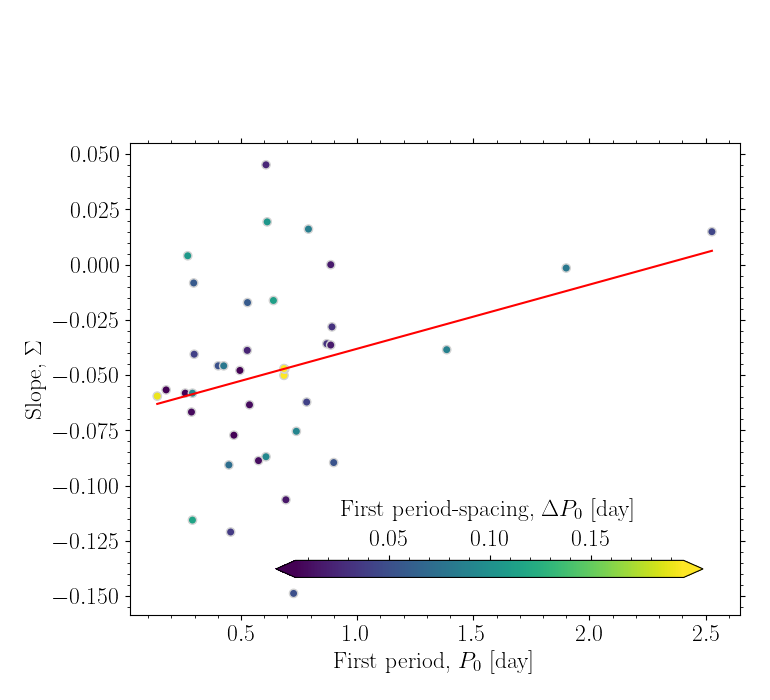

[ 0.02901858 -0.06706456]


In [8]:
# Use correct stellar rotation (slope) from fit
def func(x, a, b): return a * x + b
P0_range  = np.linspace(dm.P0.min(), dm.P0.max(), 100)
popt, pcov = curve_fit(func, dm.P0, dm.slope)
print(popt)

# Plot period spacing pattern
fig, ax = plt.subplots(1, 1, figsize=(7.7,7))
im0 = ax.scatter(dm.P0, dm.slope, c=dm.dP0, edgecolors='lightgray', cmap='viridis')
ax.plot(P0_range, func(P0_range, *popt), 'r-')
ax.set_xlabel('First period, $P_0$ [day]')
ax.set_ylabel('Slope, $\Sigma$')
cbar = plt.colorbar(im0, orientation='horizontal', location='top', extend='both', 
                   anchor=(0.8, -6.5), shrink=0.7, aspect=25)
cbar.set_label(r"First period-spacing, $\Delta P_0$ [day]", labelpad=10)                                    
plt.tight_layout()

### Model used by varsim

<IPython.core.display.Javascript object>


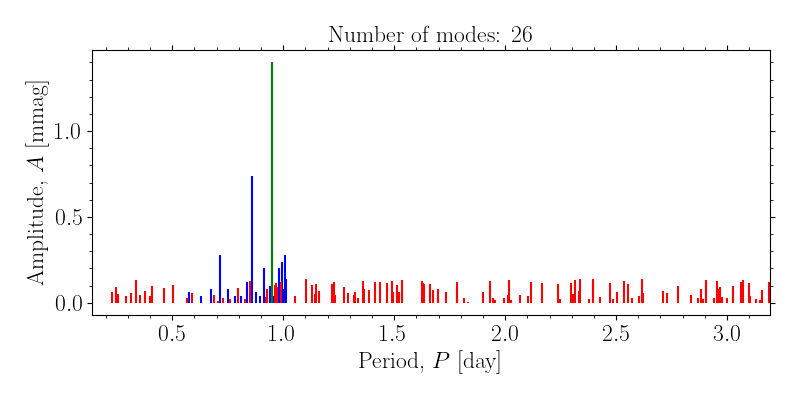

In [62]:
#----- Modes in pattern
n = 1000

# Select number modes
N_ran = np.arange(dm.N.min(), dm.N.max(), 1)
N = pd.Series(N_ran).sample(1, weights=N_kde(N_ran)).to_numpy()[0]
N = int(N)

# First period in pattern from KDE
P0_ran = np.linspace(dm.P0.min(), dm.P0.max(), n)
P0 = pd.Series(P0_ran).sample(1, weights=P0_kde(P0_ran)).to_numpy()[0]

# First period spacing in pattern from KDE
dP0_ran = np.linspace(dm.dP0.min(), dm.dP0.max(), n)
dP0 = pd.Series(dP0_ran).sample(1, weights=dP0_kde(dP0_ran)).to_numpy()[0]

# Slope of pattern from KDE
slope_ran = np.linspace(dm.slope.min(), dm.slope.max(), n)
slope = pd.Series(slope_ran).sample(1, weights=slope_kde(slope_ran)).to_numpy()[0]

# Create period-spacing pattern
P_i = np.array([dP0 * ((1 + slope)**i - 1)/slope + P0 for i in range(N)])

# Draw amplitude below maximum
A_i_ran = np.linspace(0, 0.02, n)
param   = [1.4225080146060183, 8.415648200068788e-07, 0.00012715214085614303]
A_i_fit = ss.lognorm.pdf(A_i_ran, param[0], loc=param[1], scale=param[2])
A_i = pd.Series(A_i_ran).sample(N, weights=A_i_fit, replace=True).to_numpy()

# Max peak amplitude
n_max = np.argmax(A_i)
A_max = A_i[n_max]

# Swap max peak location with offset
n_off = np.random.randint(-5, 5)
n_dex = int(N/2 + n_off)
if n_dex > n_off/2: n_dex = int(n_dex - 1) 
A_i[n_max] = A_i[n_dex]
A_i[n_dex] = A_max

# Draw random periods not part of the pattern
M = np.random.randint(100, 300)
P_puls_i = np.random.uniform(0.2, 3.5, size=M)
A_puls_i = np.random.uniform(0, A_max/10, size=M)

# Plot periodogram
fig, ax = plt.subplots(1,1, figsize=(8,4))
for i in range(N):
    ax.vlines(x=P_i[i], ymin=0, ymax=A_i[i]*1e3, colors='b', label='Pattern')
for i in range(M):
    ax.vlines(x=P_puls_i[i], ymin=0, ymax=A_puls_i[i]*1e3, colors='r', label='Extra pulsations')
ax.vlines(x=P_i[n_dex], ymin=0, ymax=A_i[n_dex]*1e3, colors='g', label='Max puls')
plt.title(f'Number of modes: {N}')
plt.xlabel(r'Period, $P$ [day]')
plt.ylabel(r'Amplitude, $A$ [mmag]')
plt.xlim(df.per.min(), df.per.max())
plt.tight_layout();

# time = np.arange(0, 30, 25/86400)
# ns.timeSeriesFromFourier(time, P_, self.df.ampl, self.df.phase, power=self.power, title=self.starname, plot=plot)
# time

---
## $\delta$ Scuti stars (Bowman+2018)
---

In [25]:
# Units from file: freq [c/d], ampl [mmag]
filenames = glob.glob(f'{vdir}/varsource_dsct_bowman2018/*.txt')
N = len(filenames)
df = pd.DataFrame()
N_mode = np.zeros(N)
A_max  = np.zeros(N)

for i,f in zip(range(N), tqdm(filenames, bar_format=ut.tqdmBar())):
    df_i = pd.read_csv(f, sep='  ',
                       names=['niter', 'freq', 'freq_err', 'ampl', 'ampl_err', 
                              'phase', 'phase_err', 'snr'])              
    df = pd.concat([df, df_i])
    N_mode[i] = df_i.shape[0]
    A_max[i]  = df_i.ampl.max()

# Remove very low frequencies
df = df[~(df.freq < 3)]
df.ampl /= 1e3
A_mag  = df.ampl
A_mmag = A_mag * 1e3

# Generate data to be used in varsim
# df = df.reset_index(drop=True)
# df.to_feather(f'{vdir}/varsim_mocka_dsct_bowman2018.ftr')
# dm = pd.DataFrame()
# dm['N'] = N_mode
# dm['A_max'] = A_max
# dm.to_feather(f'{vdir}/varsim_mocka_dsct_bowman2018_modes.ftr')

 99%|█████████████████████████████████████████████████▋| 185/186 [00:00<00:00, 1


In [26]:
# Compute KDEs
N_kde = scipy.stats.gaussian_kde(N_mode)
f_kde = scipy.stats.gaussian_kde(df.freq)

# Fit log-norm function to mode amplitudes
grid = 10000
A_range_mag  = np.linspace(0, A_mag.max(), grid)
A_range_max  = np.linspace(0, A_max.max(), grid)
A_range_mmag = np.linspace(0, A_mmag.max(), grid)
param_mag  = ss.lognorm.fit(A_mag)
param_mmag = ss.lognorm.fit(A_mmag)
A_lognorm_mag  = ss.lognorm.pdf(A_range_mag,  param_mag[0],  loc=param_mag[1],  scale=param_mag[2])  + 1e-5
A_lognorm_mmag = ss.lognorm.pdf(A_range_mmag, param_mmag[0], loc=param_mmag[1], scale=param_mmag[2]) + 1e-5

# Fit coefficient used by varsim
print(param_mag)
print(param_mmag)

(1.292324285308427, 6.511326257095987e-06, 0.00037920024297689924)
(1.2923242853085715, 0.006511326257114947, 0.37920024297685706)


<IPython.core.display.Javascript object>


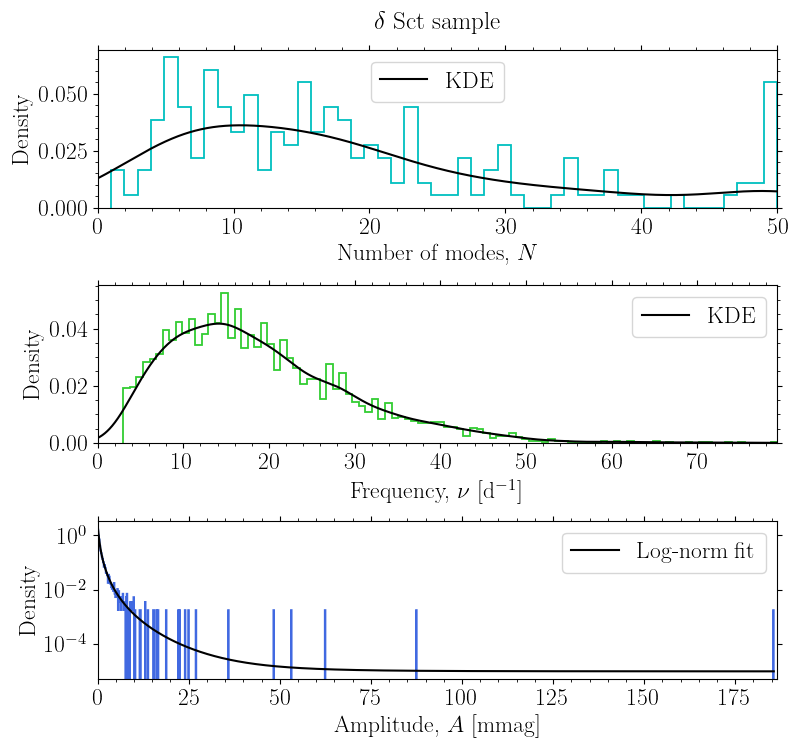

In [27]:
# Histograms
panels = 3
fig, ax = plt.subplots(panels, 1, figsize=(8, 2.5*panels))

h = ax[0].hist(N_mode, bins=50, histtype='step', density=True, ec='c', lw=1.3)
N_range = np.linspace(0, h[1].max(), grid)
N_kde_hist = N_kde(N_range)
ax[0].plot(N_range, N_kde_hist, 'k-', label='KDE')
ax[0].set_xlim(0, N_range.max())
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(df.freq, bins=100, histtype='step', density=True, ec='limegreen', lw=1.3)
f_range = np.linspace(0, h[1].max(), grid)
f_kde_hist = f_kde(f_range)
ax[1].plot(f_range, f_kde_hist, 'k-', label='KDE')
ax[1].set_xlim(0, f_range.max())
ax[1].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[1].set_ylabel('Density')

ax[2].hist(A_mmag, bins=1000, histtype='step', density=True, ec='royalblue', lw=1.3)
ax[2].plot(A_range_mmag, A_lognorm_mmag, 'k-', label='Log-norm fit')
ax[2].set_xlabel(r'Amplitude, $A$ [mmag]')
ax[2].set_yscale('log')
ax[2].set_xlim(0, A_mmag.max()+1)

ax[0].set_title(r'$\delta$ Sct sample', pad=15, fontsize=18)
for i in range(panels): 
    ax[i].set_ylabel('Density')
    ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{pdir}/varsource_hist_DSCT.png', bbox_inches='tight', dpi=200)

### Validate distributions

<IPython.core.display.Javascript object>


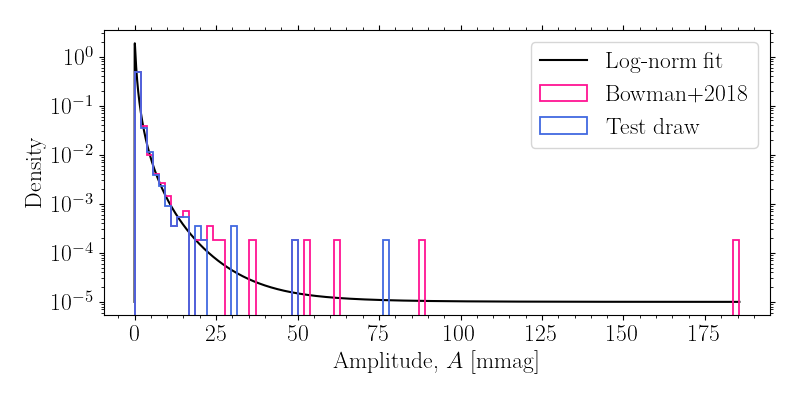

In [28]:
# TEST LOG-NORM AMPLITUDE METHODOLOGY

# Random draws using weights
N = len(A_mmag)
import random
A_i = np.array(random.choices(A_range_mmag, A_lognorm_mmag, k=N)) 
Amax = np.max([A_mmag.max(), A_i.max()])

# Inspect uncertainties
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.plot(A_range_mmag, A_lognorm_mmag, 'k-', label='Log-norm fit')
ax.hist(A_mmag, bins=100, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='deeppink',  label='Bowman+2018')
ax.hist(A_i,    bins=100, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='royalblue', label='Test draw')
ax.set_xlabel(r'Amplitude, $A$ [mmag]')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()

100%|██████████████████████████████████████████████████| 186/186 [00:06<00:00, 2


<IPython.core.display.Javascript object>


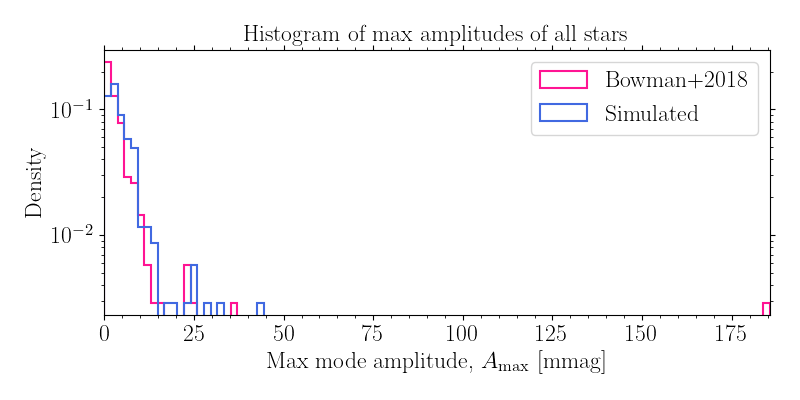

In [15]:
# VALIDATE RECOVERY OF MAX AMPLITUDE DISTRIBUTION

# Random draws
rng = ut.rng()
m = len(A_max)
A_max_draw = np.zeros(m)
for i in tqdm(range(m), bar_format=ut.tqdmBar()):
    N = int(random.choices(N_range, weights=N_kde(N_range), k=1)[0])
    if N < 5: N = 5
    n = rng.integers(10000, 100000, 1)[0]
    A_i_ran = np.linspace(0, A_max.max(), n)
    A_i_fit = scipy.stats.lognorm.pdf(A_i_ran, param_mmag[0], loc=param_mmag[1], scale=param_mmag[2])
    A_i = np.array(random.choices(A_i_ran, weights=A_i_fit, k=N))
    A_max_draw[i] = A_i.max()
    
# Plot validation
Amax = np.max([A_max.max(), A_max_draw.max()])
fig, ax = plt.subplots(1, 1, figsize=(8,4))
h = ax.hist(A_max,      bins=100, range=(0, Amax), histtype='step', density=True, lw=1.5, ec='deeppink',  label='Bowman+2018')
h = ax.hist(A_max_draw, bins=100, range=(0, Amax), histtype='step', density=True, lw=1.5, ec='royalblue', label='Simulated')
ax.set_xlim(0, A_range_max.max())
ax.set_xlabel(r'Max mode amplitude, $A_{\rm max}$ [mmag]')
ax.set_ylabel('Density')
ax.set_title('Histogram of max amplitudes of all stars')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()

---
## $\beta$ Cephei stars (Hey & Aerts 2024)
---

In [11]:
# Extract modes
df = pd.read_csv(f'{vdir}/allHighFreqSignals_betaCepSprint.csv')
rows = 187

# Remove stars with extremely high number of modes
df = df[~(df.N_signals > 75)]

# Fetch all modes in loop
N_mode = df.N_signals
f_mode = []
A_mode = []
p_mode = []

for i in range(1,rows+1):
    freqs = df[f'f{i}'].to_numpy()
    ampls = df[f'a{i}'].to_numpy()
    phase = df[f'p{i}'].to_numpy()
     
    # Remove modes below 3 c/d
    dex = np.where(freqs > 3)[0]
    if len(dex) != 0:  
        freqs = freqs[dex].tolist()
        ampls = ampls[dex].tolist()
        phase = phase[dex].tolist()
        f_mode.append(freqs)
        A_mode.append(ampls)
        p_mode.append(phase)
        
# Combine all lists into a merged list object
f_mode = np.array([x for xs in f_mode for x in xs]).flatten()
A_mode = np.array([x for xs in A_mode for x in xs]).flatten()
p_mode = np.array([x for xs in p_mode for x in xs]).flatten()
f_mode = f_mode[~np.isnan(f_mode)]
A_mode = A_mode[~np.isnan(A_mode)]
p_mode = p_mode[~np.isnan(p_mode)]

# Compute KDEs
N_kde = scipy.stats.gaussian_kde(N_mode)
f_kde = scipy.stats.gaussian_kde(f_mode)

# Save feather file for varsim
# dm = pd.DataFrame({'freq':f_mode, 'ampl':A_mode, 'phase':p_mode})
# dm.to_feather(f'{vdir}/varsim_mocka_bcep_hey2024.ftr')

In [12]:
# Log-norm fit to amplitudes
grid = 1000
A_mode *= 1e3
A_range = np.linspace(0, A_mode.max(), grid)
param = ss.lognorm.fit(A_mode) # fit the sample data
A_lognorm = ss.lognorm.pdf(A_range, param[0], loc=param[1], scale=param[2]) + 1e-5

<IPython.core.display.Javascript object>


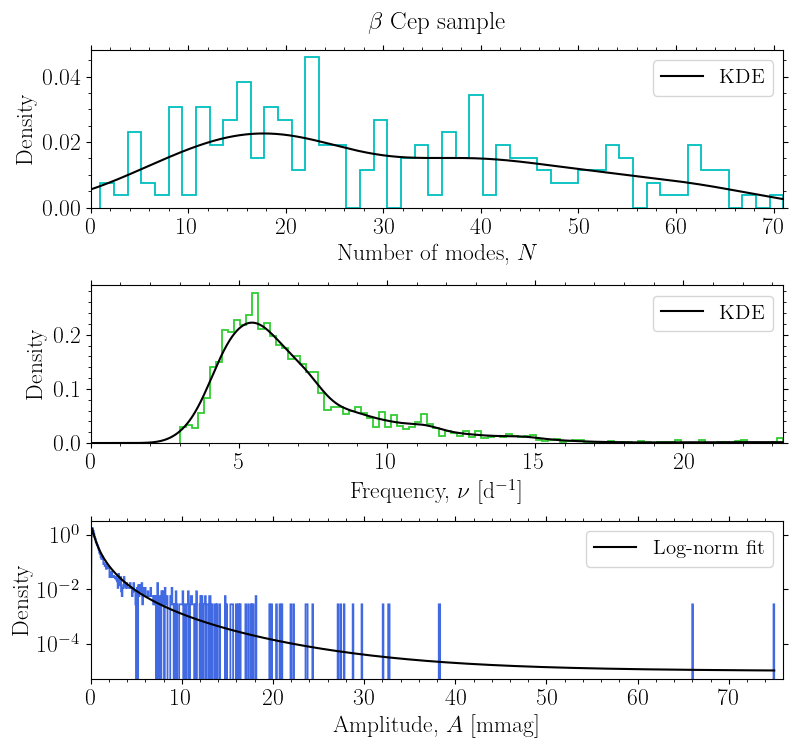

In [18]:
# Histograms
grid, panels = 10000, 3
fig, ax = plt.subplots(panels, 1, figsize=(8, 2.5*panels))

h = ax[0].hist(N_mode, bins=50, histtype='step', density=True, ec='c', lw=1.3)
N_range = np.linspace(0, h[1].max(), grid)
N_kde_hist = N_kde(N_range)
ax[0].plot(N_range, N_kde_hist, 'k-', label='KDE')
ax[0].set_xlim(0, N_range.max())
ax[0].set_xlabel(r'Number of modes, $N$')

h = ax[1].hist(f_mode, bins=100, histtype='step', density=True, ec='limegreen', lw=1.3)
f_range = np.linspace(0, h[1].max(), grid)
f_kde_hist = f_kde(f_range)
ax[1].plot(f_range, f_kde_hist, 'k-', label='KDE')
ax[1].set_xlim(0, f_range.max())
ax[1].set_xlabel(r'Frequency, $\nu$ [d$^{-1}$]')
ax[1].set_ylabel('Density')

ax[2].hist(A_mode, bins=1000, histtype='step', density=True, ec='royalblue', lw=1.3)
ax[2].plot(A_range, A_lognorm, 'k-', label='Log-norm fit')
ax[2].set_xlabel(r'Amplitude, $A$ [mmag]')
ax[2].set_yscale('log')
ax[2].set_xlim(0, A_mode.max()+1)
# ax[2].set_xscale('log')

ax[0].set_title(r'$\beta$ Cep sample', pad=15, fontsize=18)
for i in range(panels): 
    ax[i].set_ylabel('Density')
    ax[i].legend(loc='best')
plt.tight_layout(pad=0.5);

# Save figure
# fig.savefig(f'{pdir}/varsource_hist_BCEP.png', bbox_inches='tight', dpi=200)

### Validate distribution

<IPython.core.display.Javascript object>


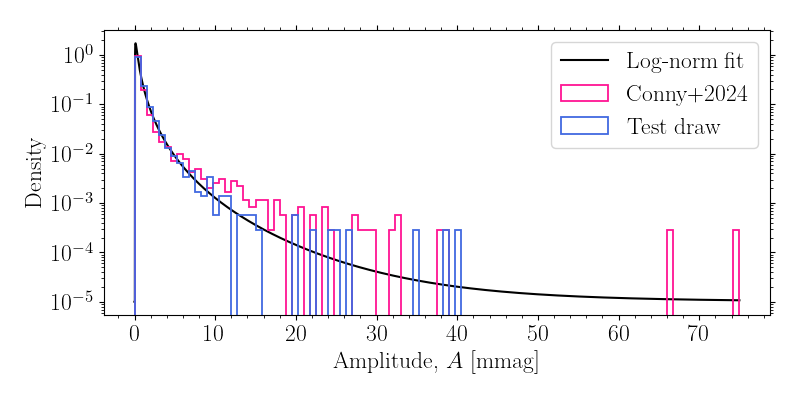

In [211]:
# TEST LOG-NORM AMPLITUDE METHODOLOGY

# Random draws using weights
N = len(A_mode)
A_i = np.array(random.choices(A_range, A_lognorm, k=N)) 
Amax = np.max([A_mode.max(), A_i.max()])

# Inspect uncertainties
fig, ax = plt.subplots(1,1, figsize=(8,4))
ax.plot(A_range, A_lognorm, 'k-', label='Log-norm fit')
ax.hist(A_mode, bins=100, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='deeppink',  label='Hey+2024')
ax.hist(A_i,    bins=100, range=(0, Amax), histtype='step', density=True, lw=1.3, ec='royalblue', label='Test draw')
ax.set_xlabel(r'Amplitude, $A$ [mmag]')
ax.set_ylabel('Density')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()

In [ ]:
# VALIDATE RECOVERY OF MAX AMPLITUDE DISTRIBUTION

# Random draws
rng = ut.rng()
m = len(A_max)
A_max_draw = np.zeros(m)
for i in tqdm(range(m), bar_format=ut.tqdmBar()):
    N = int(random.choices(N_range, weights=N_kde(N_range), k=1)[0])
    if N < 5: N = 5
    n = rng.integers(10000, 100000, 1)[0]
    A_i_ran = np.linspace(0, A_max.max(), n)
    A_i_fit = scipy.stats.lognorm.pdf(A_i_ran, param_mmag[0], loc=param_mmag[1], scale=param_mmag[2])
    A_i = np.array(random.choices(A_i_ran, weights=A_i_fit, k=N))
    A_max_draw[i] = A_i.max()
    
# Plot validation
Amax = np.max([A_max.max(), A_max_draw.max()])
fig, ax = plt.subplots(1, 1, figsize=(8,4))
h = ax.hist(A_max,      bins=100, range=(0, Amax), histtype='step', density=True, lw=1.5, ec='deeppink',  label='Bowman+2018')
h = ax.hist(A_max_draw, bins=100, range=(0, Amax), histtype='step', density=True, lw=1.5, ec='royalblue', label='Simulated')
ax.set_xlim(0, A_range_max.max())
ax.set_xlabel(r'Max mode amplitude, $A_{\rm max}$ [mmag]')
ax.set_ylabel('Density')
ax.set_title('Histogram of max amplitudes of all stars')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()

In [199]:
# # Load all files into one data frame
# skip = [5, 6, 54, 59, 76, 77, 82, 129, 131, 133, 149, 163, 165, 166, 185, 190, 194]
# dv = pd.DataFrame()
# for f in tqdm(filenames, bar_format=ut.tqdmBar()):
#     if not i == skip:
#         dv_i = pd.read_csv(filenames[0], skiprows=22, sep='           ', names=['freq', 'ampl'])   
#         dv = pd.concat([dv, dv_i])

---
## RR Lyrae stars (Attila Bodi)
---

In [ ]:
filenames = glob.glob(f'{vdir}/varsource_rrly_bodi2023/*.fou')

In [ ]:
dv_i = pd.read_csv(f, sep='  ',
                       names=['niter', 'freq', 'freq_err', 'ampl', 'ampl_err', 
                              'phase', 'phase_err', 'snr'])              
    dv = pd.concat([dv, dv_i])

In [ ]:
dv = pd.DataFrame()
for f in tqdm(filenames, bar_format=ut.tqdmBar()):
    dv_i = pd.read_csv(f, sep='  ',
                       names=['niter', 'freq', 'freq_err', 'ampl', 'ampl_err', 
                              'phase', 'phase_err', 'snr'])              
    dv = pd.concat([dv, dv_i])

---
## Eclipsing binaries
---

---
## Solar-like variability
---

### Solar flare model

<IPython.core.display.Javascript object>


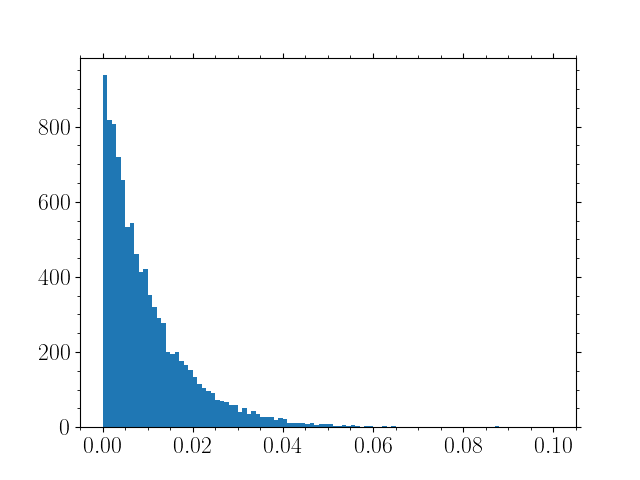

array([0.05339411, 0.02409439, 0.01541899])

In [37]:
rng = ut.rng()
x = rng.exponential(0.01, 10000)
y = rng.exponential(0.1, 3)
plt.figure()
plt.hist(x, bins=100);
y

<IPython.core.display.Javascript object>


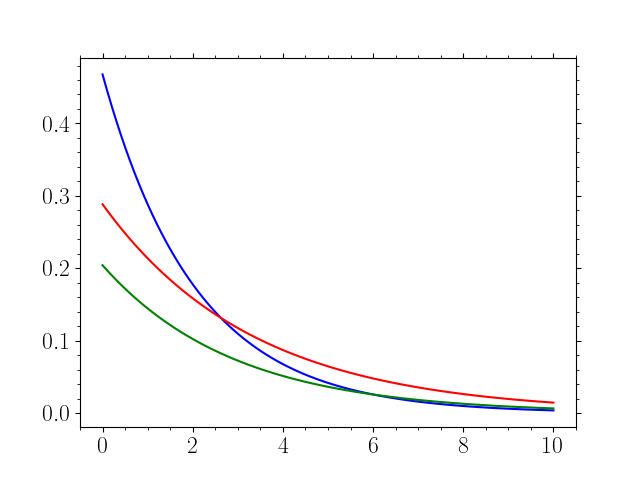

In [38]:
# These are the rates from 
a_rate_F, b_rate_F = -0.21, -0.33
a_rate_G, b_rate_G = -0.15, -0.69
a_rate_K, b_rate_K = -0.13, -0.54
x = np.linspace(0, 10, 100)
rate_F = a_rate_F * x + b_rate_F
rate_G = a_rate_G * x + b_rate_G
rate_K = a_rate_K * x + b_rate_K

plt.figure()
plt.plot(x, 10**rate_F, 'b-')
plt.plot(x, 10**rate_G, 'g-')
plt.plot(x, 10**rate_K, 'r-')

<IPython.core.display.Javascript object>


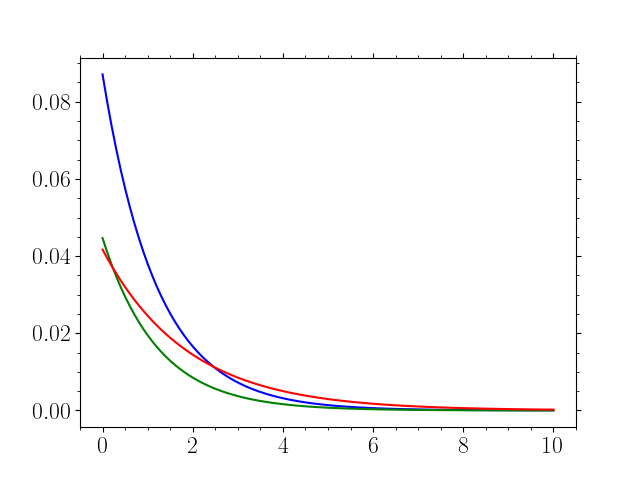

In [39]:
# Flare amplitude as function of spectral types 
a_A_F, b_A_F = -0.36, -1.06 
a_A_G, b_A_G = -0.36, -1.35 
a_A_K, b_A_K = -0.23, -1.38 

x = np.linspace(0, 10, 100)
A_F = a_A_F * x + b_A_F
A_G = a_A_G * x + b_A_G
A_K = a_A_K * x + b_A_K

plt.figure()
plt.plot(x, 10**A_F, 'b-')
plt.plot(x, 10**A_G, 'g-')
plt.plot(x, 10**A_K, 'r-')

### Stellar activity model

In [ ]:
from platosim.varsource import StellarSpots, StellarFlares

# Observational parameters
seed = 2
tcad = 3600                            # [s]
tdur = 720                             # [d]
time = np.arange(0, tdur, tcad/86500)  # [d]

# Stellar parameters
spec = 'G'
Teff = 5800
incl = 90

# Generate spots
model_spot = StellarSpots(seed=seed)
lc, params, spot_coverage = model_spot.evaluate(teff=Teff, time=time, dur=tdur, cadence_hours=tcad/3600, incl=incl)
AR_ARsun = params[2]

# Generate flares
model_flare = StellarFlares(time, seed=seed)
params = model_flare.initDoorsselaere2017(spec, AR_ARsun, spot_coverage)
lc, df = model_flare.evaluate()
flux_flare = (lc - 1) * 1e3
print(params)

# Plot for paper
fig, ax = model_spot.plot(title=False, panels=4, figsize=(8,8))
ax[3].plot(time, flux_flare, 'k-')
ax[3].set_ylabel('Flare flux [ppt]')
plt.gcf().text(0.15, 0.92, 'a)', fontsize=20)
plt.gcf().text(0.15, 0.70, 'b)', fontsize=20)
plt.gcf().text(0.15, 0.35, 'c)', fontsize=20)
plt.gcf().text(0.15, 0.26, 'd)', fontsize=20)
for i in range(4): ax[i].get_yaxis().set_label_coords(-0.08, 0.5)
# fig.savefig(f'{fdir}/stellar_activity.png', bbox_inches='tight', dpi=200)